<a href="https://colab.research.google.com/github/brahmanbhavika06-sketch/my-colab-code/blob/main/19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: cardekho.csv            


In [ ]:
import pandas as pd

# Load Dataset
df = pd.read_csv("cardekho.csv")

# Display first 10 rows
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


In [ ]:
# Check missing values
missing = df.isnull().sum()
print("Missing Values:")
print(missing)

# Calculate missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentage:")
print(missing_percentage)

Missing Values:
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

Missing Value Percentage:
name                  0.000000
year                  0.000000
selling_price         0.000000
km_driven             0.000000
fuel                  0.000000
seller_type           0.000000
transmission          0.000000
owner                 0.000000
mileage(km/ltr/kg)    2.718996
engine                2.718996
max_power             2.645177
seats                 2.718996
dtype: float64


In [ ]:
# Remove missing values
df = df.dropna()

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 1189


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check dataset shape after cleaning
print("Dataset Shape:", df.shape)

Dataset Shape: (6718, 12)


In [ ]:
# Statistical Summary
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,7907.000000,7.907000e+03,7.907000e+03,7907.000000,7907.000000,7907.000000
mean,2013.982168,6.497417e+05,6.919256e+04,19.418783,1458.625016,5.416719
std,3.866650,8.135565e+05,5.678976e+04,4.037145,503.916303,0.959588
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2012.000000,2.700000e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.900000e+05,9.575000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [ ]:
# Target Variable Statistics
print("Minimum Selling Price:", df['selling_price'].min())
print("Maximum Selling Price:", df['selling_price'].max())
print("Mean Selling Price:", df['selling_price'].mean())
print("Median Selling Price:", df['selling_price'].median())

Minimum Selling Price: 29999
Maximum Selling Price: 10000000
Mean Selling Price: 649741.6563804224
Median Selling Price: 450000.0


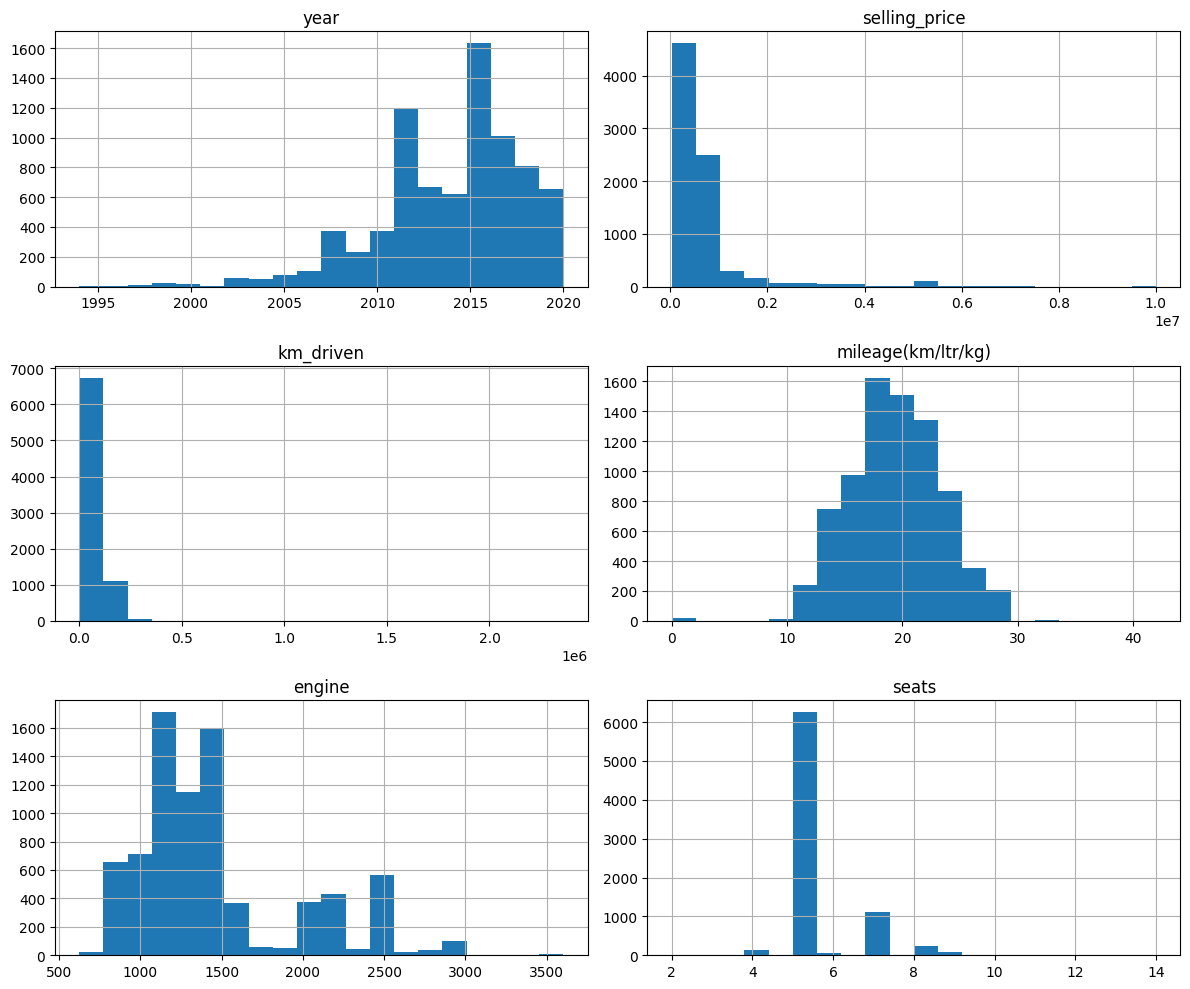

In [ ]:
import matplotlib.pyplot as plt

# Select numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[numeric_columns].hist(figsize=(12,10), bins=20)

plt.tight_layout()
plt.show()

In [ ]:
# Check categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner', 'max_power'], dtype='object')


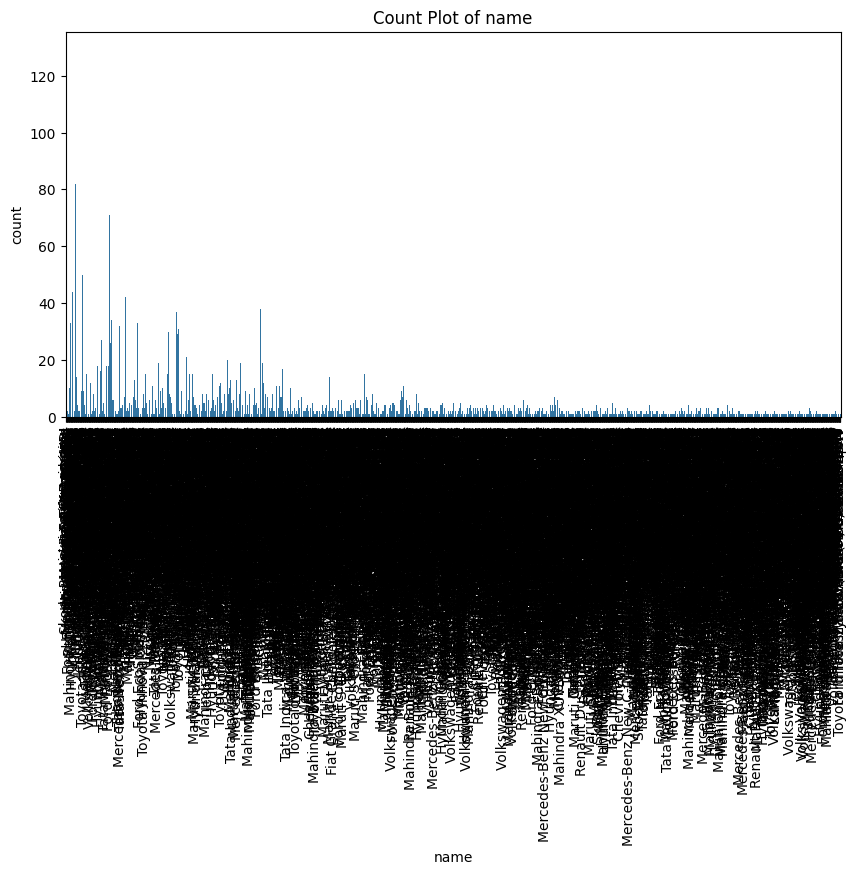

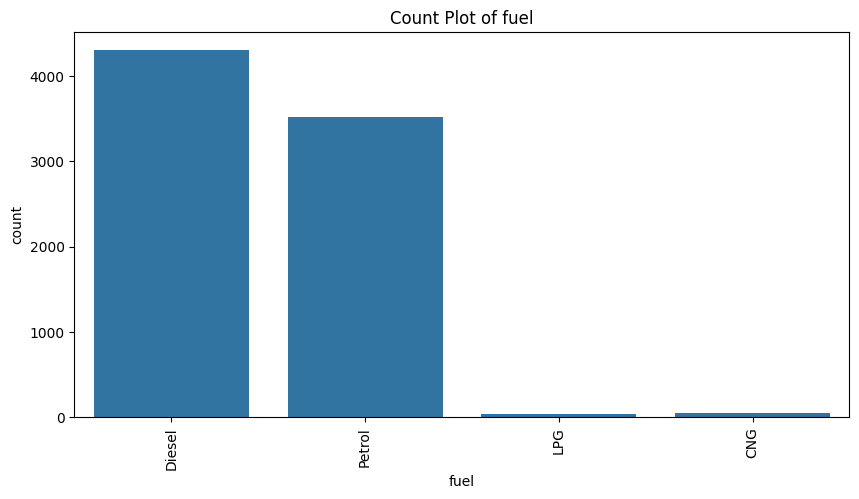

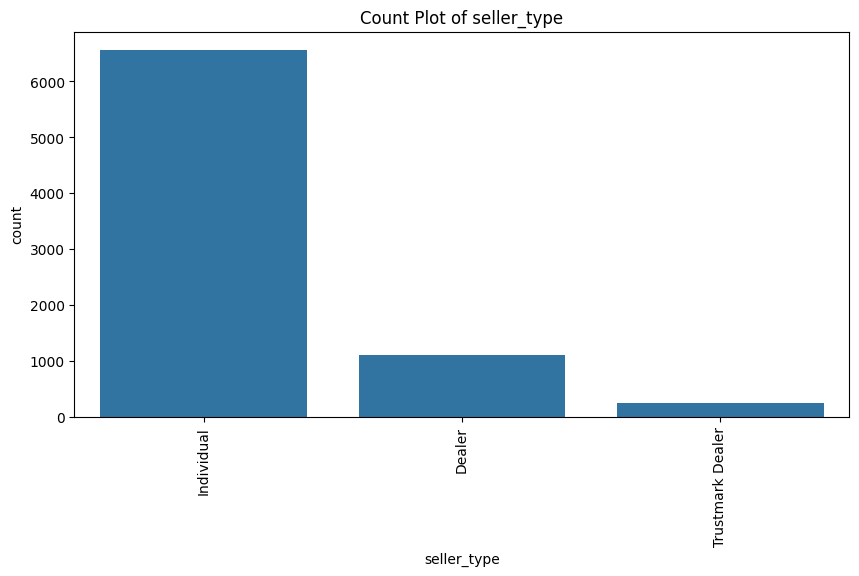

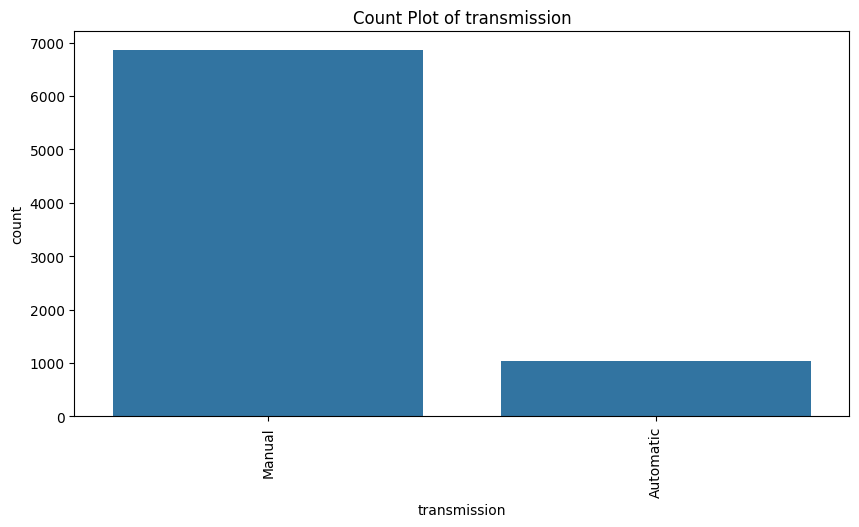

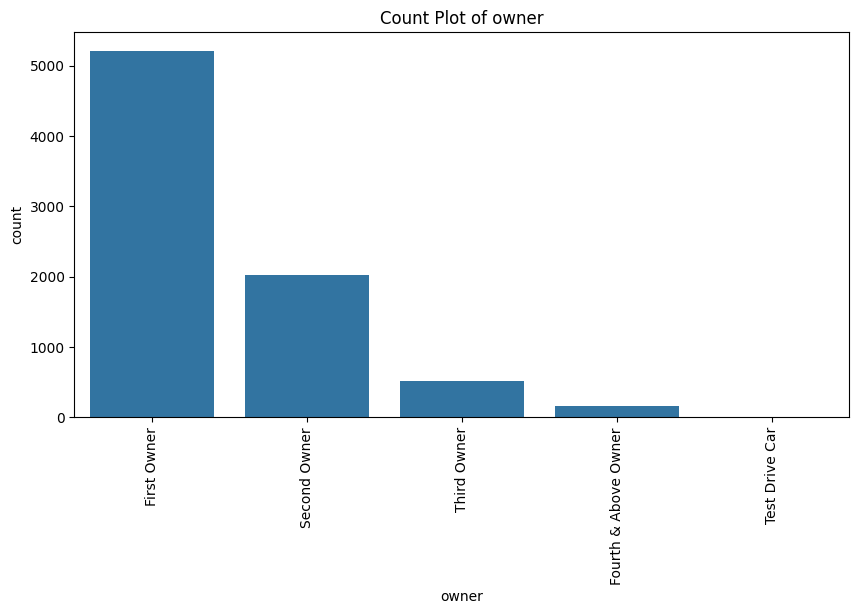

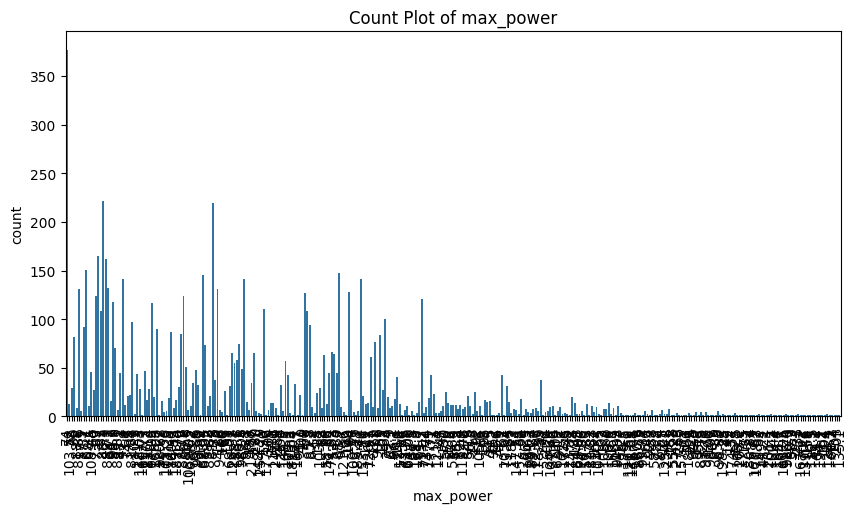

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'max_power']

for col in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.title(f"Count Plot of {col}")
    plt.show()

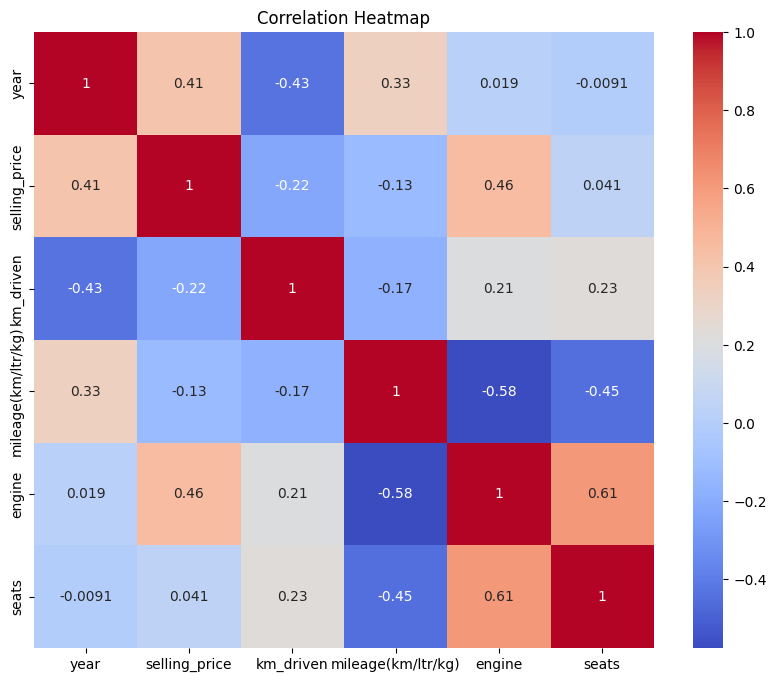

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Independent Features (X)
X = df.drop('selling_price', axis=1)

# Dependent Feature (y)
y = df['selling_price']

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission',
       'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats'],
      dtype='object')

Dependent Feature (y):
selling_price


In [ ]:
# Show categorical columns before encoding
print("Before Encoding:")
print(df[['fuel', 'seller_type']].head())

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Show columns after encoding
print("\nAfter Encoding:")
print(df_encoded.head())

Before Encoding:
     fuel seller_type
0  Diesel  Individual
1  Diesel  Individual
2  Petrol  Individual
3  Diesel  Individual
4  Petrol  Individual

After Encoding:
   year  selling_price  km_driven  mileage(km/ltr/kg)  engine  seats  \
0  2014         450000     145500               23.40  1248.0    5.0   
1  2014         370000     120000               21.14  1498.0    5.0   
2  2006         158000     140000               17.70  1497.0    5.0   
3  2010         225000     127000               23.00  1396.0    5.0   
4  2007         130000     120000               16.10  1298.0    5.0   

   name_Ambassador Classic 2000 DSZ AC PS  \
0                                   False   
1                                   False   
2                                   False   
3                                   False   
4                                   False   

   name_Ambassador Grand 1500 DSZ BSIII  name_Ambassador Grand 2000 DSZ PW CL  \
0                                 False          

In [ ]:
from sklearn.preprocessing import StandardScaler

# Independent features
X = df_encoded.drop('selling_price', axis=1)

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show first 5 rows
print("First 5 rows of Scaled Features:")
print(X_scaled[:5])

First 5 rows of Scaled Features:
[[ 0.00461211  1.34376809  0.98620891 ... -0.06949155 -0.02249749
  -0.03375691]
 [ 0.00461211  0.89471509  0.42637197 ... -0.06949155 -0.02249749
  -0.03375691]
 [-2.06449299  1.24691352 -0.42576921 ... -0.06949155 -0.02249749
  -0.03375691]
 [-1.02994044  1.01798454  0.88712272 ... -0.06949155 -0.02249749
  -0.03375691]
 [-1.80585485  0.89471509 -0.82211394 ... -0.06949155 -0.02249749
  -0.03375691]]
